In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

data = load_diabetes()
X = data.data
y = data.target

x = X[:,2]
m = x.shape[0]

print("m =", m)
print("x range:", x.min(), x.max())
print("y range:", y.min(), y.max())

m = 442
x range: -0.09027529589850945 0.17055522598064407
y range: 25.0 346.0


In [7]:
def f_wb(x, w, b):
    return w * x + b

In [8]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    y_hat = f_wb(x, w, b)
    err = y_hat - y
    J = (1 / (2*m)) * np.sum(err ** 2)
    return J

In [10]:
w = 0
b = np.mean(y)
J = compute_cost(x, y, w, b)
print("Cost J =", J)


Cost J = 2964.9424484551914


In [22]:
b = np.mean(y)

for w in [-50, 0, 900]:
    J = compute_cost(x, y, w, b)
    print(f"w={w:>4}, b={b:.2f}  ->  J={J:.2f}")


w= -50, b=152.13  ->  J=3075.17
w=   0, b=152.13  ->  J=2964.94
w= 900, b=152.13  ->  J=1947.99


x ile y arasında pozitif ilişki var → w pozitif olunca çizgi veriye biraz daha uyuyor → cost düşüyor.

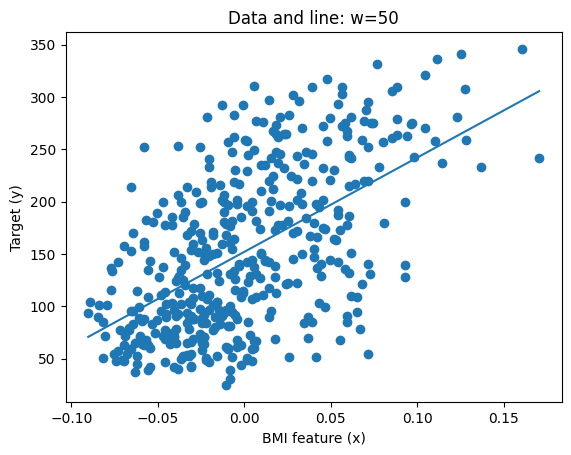

In [25]:
plt.scatter(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = 900 * x_line + b
plt.plot(x_line, y_line)
plt.xlabel("BMI feature (x)")
plt.ylabel("Target (y)")
plt.title("Data and line: w=50")
plt.show()


In [13]:
from sklearn.linear_model import LinearRegression

x2 = x.reshape(-1, 1)  # sklearn 2D ister
lr = LinearRegression()
lr.fit(x2, y)

w_best = lr.coef_[0]
b_best = lr.intercept_

print("w_best =", w_best)
print("b_best =", b_best)
print("J(w_best,b_best) =", compute_cost(x, y, w_best, b_best))


w_best = 949.4352603840387
b_best = 152.13348416289617
J(w_best,b_best) = 1945.2282927306364


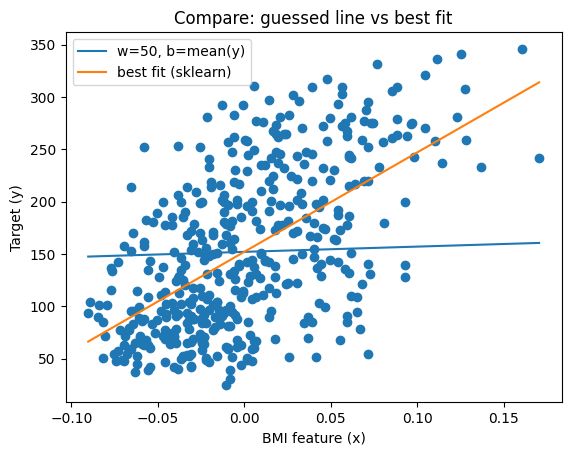

In [14]:
plt.scatter(x, y)

x_line = np.linspace(x.min(), x.max(), 100)

# senin denediğin
plt.plot(x_line, 50 * x_line + np.mean(y), label="w=50, b=mean(y)")

# sklearn en iyi
plt.plot(x_line, w_best * x_line + b_best, label="best fit (sklearn)")

plt.xlabel("BMI feature (x)")
plt.ylabel("Target (y)")
plt.title("Compare: guessed line vs best fit")
plt.legend()
plt.show()
